# Airbnb Price Prediction

## Predicting listing log-prices from structured Airbnb features

This notebook presents a complete regression workflow to predict the `log_price` of Airbnb listings from structured listing attributes.

The project follows four main steps:
- preparing the raw data and engineering useful features,
- exploring the target and the most informative drivers,
- benchmarking several regression models,
- selecting and tuning the most promising model for final predictions.


In [1]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

import folium


In [2]:
from pathlib import Path

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data" if (PROJECT_DIR / "data").exists() else PROJECT_DIR
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_DATA_PATH = DATA_DIR / "airbnb_train.csv"
TEST_DATA_PATH = DATA_DIR / "airbnb_test.csv"
SUBMISSION_TEMPLATE_PATH = DATA_DIR / "prediction_example.csv"
PREDICTIONS_PATH = ARTIFACTS_DIR / "airbnb_predictions.csv"

for required_path in [TRAIN_DATA_PATH]:
    if not required_path.exists():
        raise FileNotFoundError(
            f"Missing required file: {required_path}. Place the course CSV files in the project's data directory before running the notebook."
        )


## Data Loading

The training data is loaded from the local project `data/` directory. A quick inspection of the raw columns helps identify the variables that need cleaning, type conversion, or feature extraction before model training.


In [3]:
airbnb = pd.read_csv(TRAIN_DATA_PATH)
airbnb.head()


,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,zipcode,bedrooms,beds
0,5708593,4.317488,House,Private room,"{TV,""Wireless Internet"",Kitchen,""Free parking ...",3,1.0,Real Bed,flexible,False,...,NaN,33.782712,-118.134410,Island style Spa Studio,Long Beach,0,NaN,90804,0.0,2.0
1,14483613,4.007333,House,Private room,"{""Wireless Internet"",""Air conditioning"",Kitche...",4,2.0,Real Bed,strict,False,...,2017-09-17,40.705468,-73.909439,"Beautiful and Simple Room W/2 Beds, 25 Mins to...",Ridgewood,38,86.0,11385,1.0,2.0
2,10412649,7.090077,Apartment,Entire home/apt,"{TV,""Wireless Internet"",""Air conditioning"",Kit...",6,2.0,Real Bed,flexible,False,...,NaN,38.917537,-77.031651,2br/2ba luxury condo perfect for infant / toddler,U Street Corridor,0,NaN,20009,2.0,2.0
3,17954362,3.555348,House,Private room,"{TV,""Cable TV"",Internet,""Wireless Internet"",""A...",1,1.0,Real Bed,flexible,True,...,2017-09-29,40.736001,-73.924248,Manhattan view from Queens. Lovely single room .,Sunnyside,19,96.0,11104,1.0,1.0
4,9969781,5.480639,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,moderate,True,...,2017-08-28,37.744896,-122.430665,Zen Captured Noe Valley House,Noe Valley,15,96.0,94131,2.0,2.0


## Data Cleaning and Feature Engineering

The raw dataset contains several fields that are not directly usable in a regression model. This section creates a cleaner feature set by:
- extracting useful signals from `amenities`,
- converting boolean indicators into binary variables,
- deriving host seniority from `host_since`,
- filling missing values in a simple and consistent way.


In [4]:

def has_amenity(amenities, keyword):
    if pd.isnull(amenities): return 0
    return int(keyword.lower() in amenities.lower())

# Binary amenity features
airbnb["has_wifi"] = airbnb["amenities"].apply(lambda x: has_amenity(x, "wifi"))
airbnb["has_kitchen"] = airbnb["amenities"].apply(lambda x: has_amenity(x, "kitchen"))
airbnb["has_tv"] = airbnb["amenities"].apply(lambda x: has_amenity(x, "tv"))
airbnb["has_aircon"] = airbnb["amenities"].apply(lambda x: has_amenity(x, "air conditioning"))
airbnb["has_heating"] = airbnb["amenities"].apply(lambda x: has_amenity(x, "heating"))
airbnb["has_parking"] = airbnb["amenities"].apply(lambda x: has_amenity(x, "parking"))

# Host seniority in days
airbnb["host_since"] = pd.to_datetime(airbnb["host_since"], errors="coerce")
airbnb["host_days"] = (pd.to_datetime("today") - airbnb["host_since"]).dt.days

# Boolean mapping
bool_map = {"t": 1, "f": 0}
for col in ["cleaning_fee", "instant_bookable", "host_identity_verified", "host_has_profile_pic"]:
    airbnb[col] = airbnb[col].map(bool_map)


## Final Feature Selection

Only the variables that appear informative and reasonably stable are retained. Very noisy, redundant, or weakly interpretable columns are removed to keep the modeling pipeline readable and consistent.


In [5]:
# Selected modeling features
features = [
    "accommodates", "bathrooms", "bedrooms", "beds", "review_scores_rating", "number_of_reviews",
    "cleaning_fee", "instant_bookable", "host_identity_verified", "host_has_profile_pic",
    "host_days", "has_wifi", "has_kitchen", "has_tv", "has_aircon", "has_heating", "has_parking",
    "property_type", "room_type", "city"
]
target = "log_price"

# Drop columns with too many missing values (more than 30%)
nan_ratio = airbnb.isna().mean()
airbnb = airbnb[nan_ratio[nan_ratio < 0.3].index]

# Keep only the columns that are actually available
available_cols = [col for col in features + [target] if col in airbnb.columns]

# Keep the final columns and remove incomplete rows
airbnb = airbnb[available_cols].dropna()

# Final dataset check
print(f"Prepared dataset with {airbnb.shape[0]} rows and {airbnb.shape[1]} columns.")


Prepared dataset with 17142 rows and 20 columns.


## Exploratory Data Analysis

Before training any model, the dataset is explored to understand the target distribution and the variables that seem to drive Airbnb prices the most. The following plots help interpret the role of room type, city, capacity, and numerical correlations.


### 1. Distribution of `log_price`

The target variable is the logarithm of the listing price. Modeling `log_price` instead of the raw price makes the distribution more regular and reduces the influence of extreme values, which is generally helpful for regression.


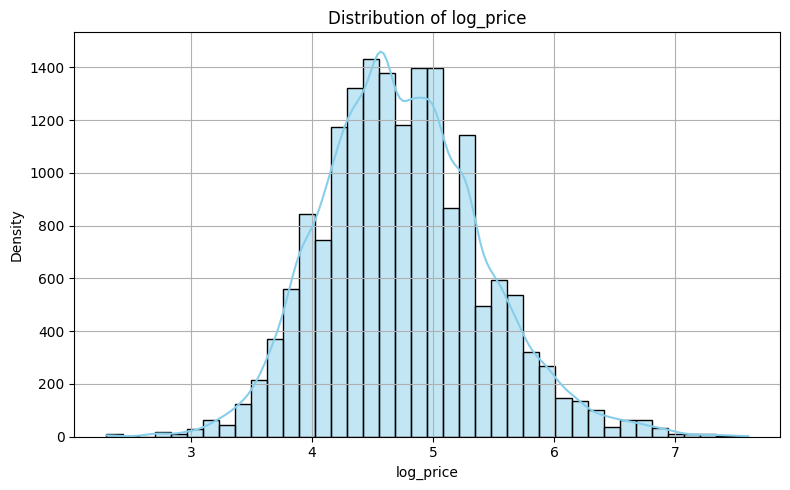

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(airbnb["log_price"], kde=True, bins=40, color="skyblue", edgecolor="black")
plt.title("Distribution of log_price")
plt.xlabel("log_price")
plt.ylabel("Density")
plt.grid(True)
plt.tight_layout()
plt.show()


### 2. `log_price` by room type

The boxplot highlights a strong relationship between room type and price level. Entire homes are typically more expensive than private rooms, while shared rooms are usually the cheapest category. This confirms that `room_type` must be preserved as a key categorical feature.


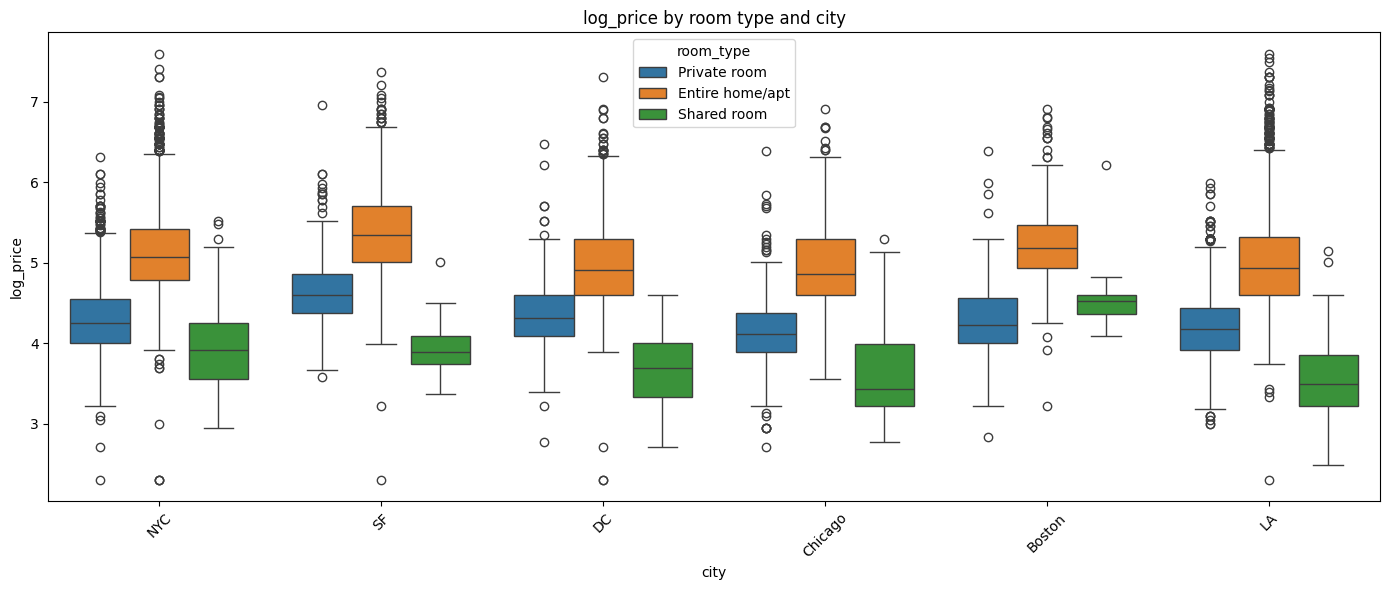

In [7]:
# Cross-analysis: log_price by room type and city
plt.figure(figsize=(14, 6))
sns.boxplot(data=airbnb, x="city", y="log_price", hue="room_type")
plt.title("log_price by room type and city")
plt.xlabel("city")
plt.ylabel("log_price")
plt.legend(title="room_type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3. Capacity versus `log_price`

The relationship between accommodation capacity and price is clearly positive, although the dispersion remains wide. Larger listings tend to be more expensive on average, which supports the use of flexible non-linear models.


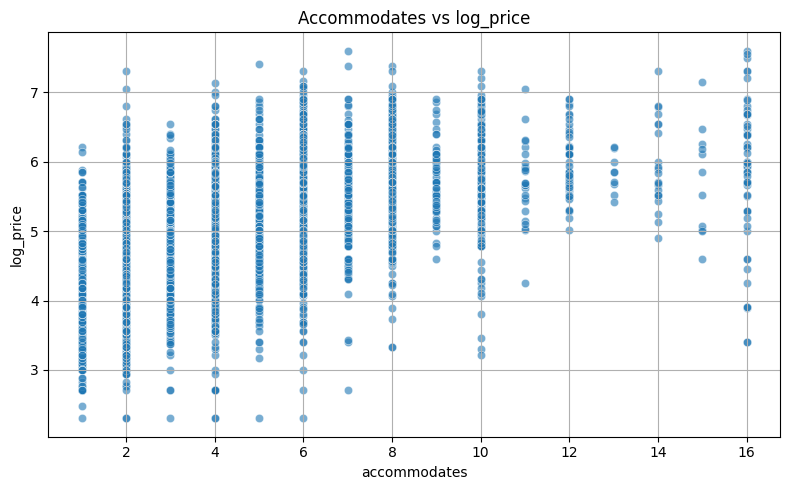

In [8]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=airbnb, x="accommodates", y="log_price", alpha=0.6)
plt.title("Accommodates vs log_price")
plt.xlabel("accommodates")
plt.ylabel("log_price")
plt.grid(True)
plt.tight_layout()
plt.show()


### 4. Average price by city

Average prices do vary across cities, even if the differences are not extreme in this sample. The plot still confirms that `city` carries useful pricing information and should be preserved in the model.


C:\Users\rmn.bm\AppData\Local\Temp\ipykernel_22596\2146755138.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_avg.index, y=city_avg.values, palette="viridis")


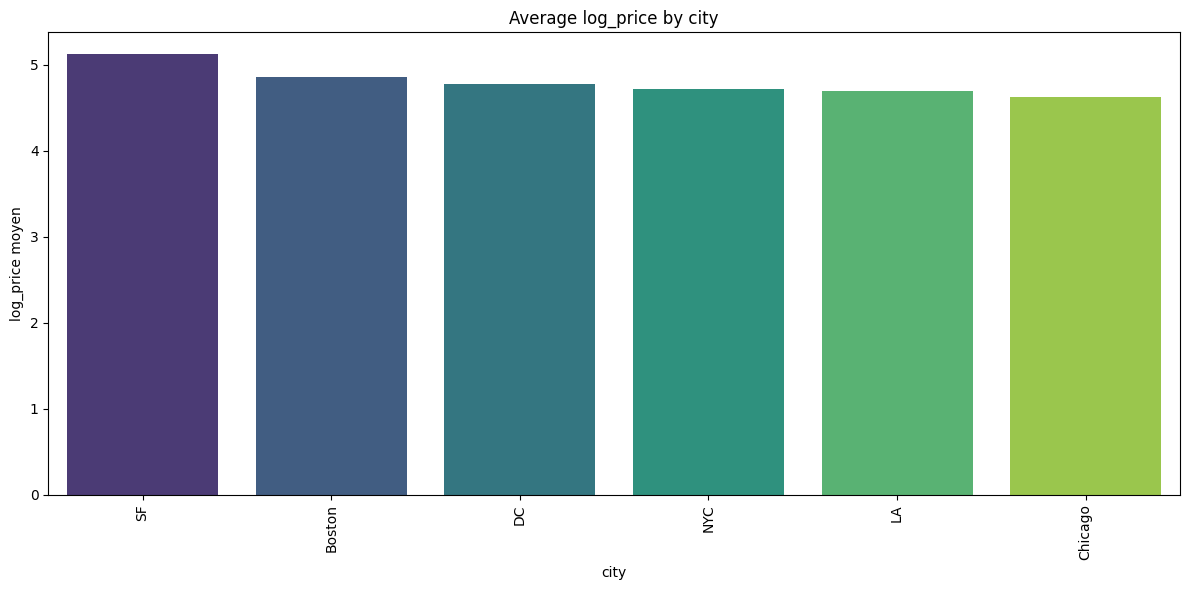

In [9]:
plt.figure(figsize=(12, 6))
city_avg = airbnb.groupby("city")["log_price"].mean().sort_values(ascending=False)
sns.barplot(x=city_avg.index, y=city_avg.values, palette="viridis")
plt.xticks(rotation=90)
plt.title("Average log_price by city")
plt.xlabel("city")
plt.ylabel("Average log_price")
plt.tight_layout()
plt.show()


### 5. Correlation with numerical variables

The correlation heatmap helps identify the numerical variables that move most closely with `log_price`. Features such as `accommodates`, `bedrooms`, `beds`, and `bathrooms` are among the strongest positive drivers, while several review and host-related variables look weaker on their own.


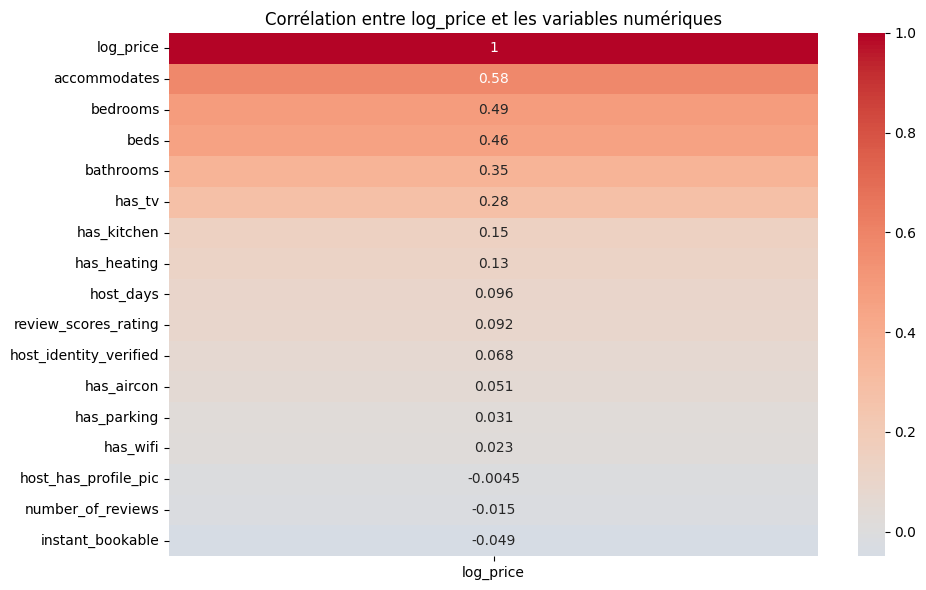

In [10]:
plt.figure(figsize=(10, 6))
correlation = airbnb.select_dtypes(include=[np.number]).corr()
sns.heatmap(
    correlation[["log_price"]].sort_values(by="log_price", ascending=False),
    annot=True,
    cmap="coolwarm",
    center=0
)
plt.title("Correlation between log_price and numerical variables")
plt.tight_layout()
plt.show()


## Train / Validation Split

The dataset is split into a training subset and a validation subset. This keeps part of the original training data aside for model comparison and helps evaluate the models on unseen observations before generating the final test predictions.


In [11]:
X = airbnb.drop("log_price", axis=1)
y = airbnb["log_price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
cat_features = ["property_type", "room_type", "city"]


## Regression Model Benchmark

Five regression models are compared on the same validation split:
- Linear Regression,
- Random Forest,
- Gradient Boosting,
- XGBoost,
- CatBoost.

The comparison uses complementary metrics:
- `R^2` for goodness of fit,
- `RMSE` and `MAE` on `log_price`,
- `MAE` in euros after reversing the log transformation,
- `MAPE` to measure relative prediction error.


In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor


In [13]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators=100),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42, n_estimators=100),
    "XGBoost": XGBRegressor(random_state=42, n_estimators=100, verbosity=0),
    "CatBoost": CatBoostRegressor(verbose=0, random_state=42, n_estimators=100)
}


## Validation Metrics

Each model is evaluated on the validation set. The goal at this stage is not only to identify the best default model, but also to understand which family of models is worth tuning further.


In [14]:
results = []
for name, model in models.items():
    if name == "Linear Regression":
        # One-hot encoding is required for Linear Regression.
        X_train_mod = pd.get_dummies(X_train, columns=["property_type", "room_type", "city"])
        X_test_mod = pd.get_dummies(X_test, columns=["property_type", "room_type", "city"])
        X_train_mod, X_test_mod = X_train_mod.align(X_test_mod, join="left", axis=1, fill_value=0)
        model.fit(X_train_mod, y_train)

    elif name == "CatBoost":
        # CatBoost can use categorical variables directly.
        X_train_mod, X_test_mod = X_train.copy(), X_test.copy()
        cat_features = ["property_type", "room_type", "city"]
        model.fit(X_train_mod, y_train, cat_features=cat_features)

    else:
        # The tree-based models below use one-hot encoded inputs in this notebook.
        X_train_mod = pd.get_dummies(X_train, columns=["property_type", "room_type", "city"])
        X_test_mod = pd.get_dummies(X_test, columns=["property_type", "room_type", "city"])
        X_train_mod, X_test_mod = X_train_mod.align(X_test_mod, join="left", axis=1, fill_value=0)
        model.fit(X_train_mod, y_train)

    y_pred = model.predict(X_test_mod)

    mae_log = mean_absolute_error(y_test, y_pred)
    rmse_log = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    y_pred_real = np.exp(y_pred)
    y_test_real = np.exp(y_test)
    mae_real = mean_absolute_error(y_test_real, y_pred_real)
    mape = np.mean(np.abs((y_test_real - y_pred_real) / y_test_real)) * 100

    results.append({
        "Model": name,
        "R^2": r2,
        "RMSE (log)": rmse_log,
        "MAE (log)": mae_log,
        "MAE (EUR)": mae_real,
        "MAPE (%)": mape,
    })

results_df = pd.DataFrame(results)
display(results_df)


,Model,R^2,RMSE (log),MAE (log),MAE (EUR),MAPE (%)
0,Linear Regression,0.612180,0.407894,0.315983,46.835350,33.527650
1,Random Forest,0.626065,0.400525,0.309611,46.499064,33.702710
2,Gradient Boosting,0.637427,0.394393,0.305722,45.547682,32.622482
3,XGBoost,0.640495,0.392721,0.301038,45.601958,32.353112
4,CatBoost,0.645674,0.389882,0.299677,45.208879,32.195013


## Visual Comparison of the Baseline Models

To summarize the baseline comparison more clearly, `R^2` and `MAPE` are visualized together. This makes it easier to compare global fit and relative error at the same time.


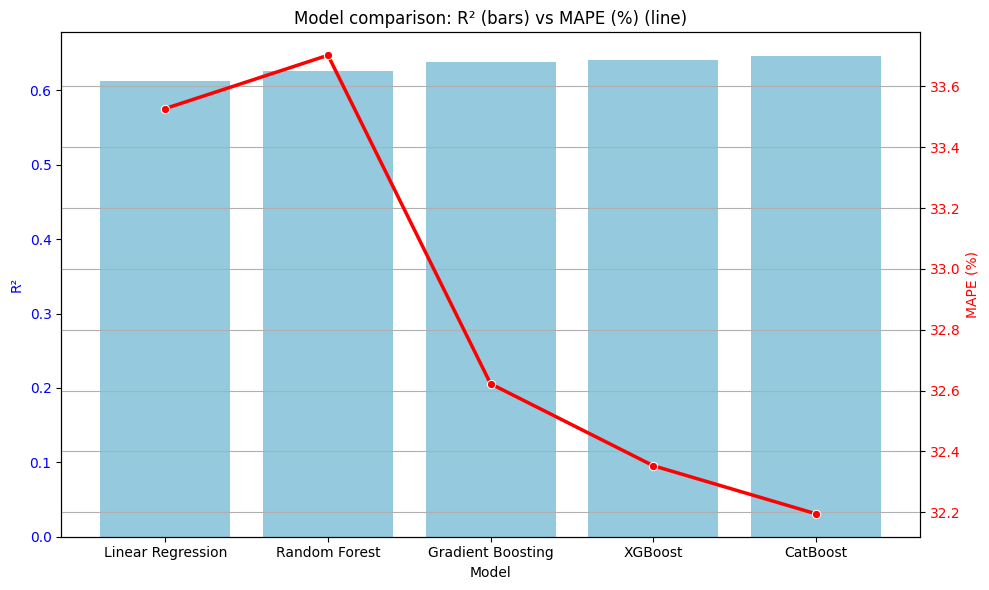

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


results_df = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting", "XGBoost", "CatBoost"],
    "R^2": [0.612180, 0.626065, 0.637427, 0.640495, 0.645674],
    "MAPE (%)": [33.527650, 33.702710, 32.622482, 32.353112, 32.195013]
})

# Combined chart
fig, ax1 = plt.subplots(figsize=(10, 6))

# Axis for R^2
sns.barplot(x="Model", y="R^2", data=results_df, color='skyblue', ax=ax1)
ax1.set_ylabel("R^2", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Secondary axis for MAPE
ax2 = ax1.twinx()
sns.lineplot(x="Model", y="MAPE (%)", data=results_df, color='red', marker='o', linewidth=2.5, ax=ax2)
ax2.set_ylabel("MAPE (%)", color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title("Model comparison: R^2 (bars) vs MAPE (%) (line)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


### Interpretation of the Baseline Results

The baseline benchmark already shows that tree-based and boosting models are better suited to this problem than a simple linear model. Among the untuned models, CatBoost is the strongest candidate, with the highest `R^2` and the lowest relative error.


## Hyperparameter Tuning

The three most promising non-linear models are tuned with `RandomizedSearchCV`:
- CatBoost,
- XGBoost,
- Random Forest.

This step is used to check whether the validation performance can be improved further once the model complexity is adjusted more carefully.


In [16]:
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor

catboost_params = {
    'depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'iterations': [100, 300, 500],
    'l2_leaf_reg': [1, 3, 5, 7]
}

# Model
cat = CatBoostRegressor(verbose=0, random_state=42)

# Randomized search
cat_search = RandomizedSearchCV(
    cat, catboost_params,
    scoring='neg_mean_absolute_error',
    n_iter=10,
    cv=3,
    verbose=1,
    n_jobs=-1
)

cat_features = ["property_type", "room_type", "city"]
cat_search.fit(X_train, y_train, cat_features=cat_features)

# Best parameters
best_catboost = cat_search.best_estimator_
print(" Best CatBoost parameters:", cat_search.best_params_)


Fitting 3 folds for each of 10 candidates, totalling 30 fits
 Best CatBoost parameters: {'learning_rate': 0.05, 'l2_leaf_reg': 3, 'iterations': 500, 'depth': 6}


### Tuned CatBoost Results

The optimized CatBoost model is evaluated on the validation subset to measure the improvement over the default configuration.


In [34]:
y_pred_opt_cat = best_catboost.predict(X_test)
mae_log = mean_absolute_error(y_test, y_pred_opt_cat)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_opt_cat))
r2 = r2_score(y_test, y_pred_opt_cat)

y_pred_real = np.exp(y_pred_opt_cat)
y_test_real = np.exp(y_test)
mae_real = mean_absolute_error(y_test_real, y_pred_real)
mape = np.mean(np.abs((y_test_real - y_pred_real) / y_test_real)) * 100

print(f"R^2 : {r2:.4f}")
print(f"MAE log : {mae_log:.4f}")
print(f"RMSE log : {rmse_log:.4f}")
print(f"MAE (EUR) : {mae_real:.2f}")
print(f"MAPE (%) : {mape:.2f}")


The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.
R² : 0.6554
MAE log : 0.2971
RMSE log : 0.3845
MAE (€) : 44.64
MAPE (%) : 31.78


### Tuning XGBoost

XGBoost is also tuned because it performed well in the baseline comparison and can capture non-linear patterns efficiently when its depth, learning rate, and number of trees are chosen carefully.


In [18]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42, verbosity=0)

xgb_params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    xgb, xgb_params,
    scoring='neg_mean_absolute_error',
    n_iter=10,
    cv=3,
    verbose=1,
    n_jobs=-1
)

X_train_enc = pd.get_dummies(X_train, columns=["property_type", "room_type", "city"])
X_test_enc = pd.get_dummies(X_test, columns=["property_type", "room_type", "city"])
X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join='left', axis=1, fill_value=0)

xgb_search.fit(X_train_enc, y_train)

best_xgb = xgb_search.best_estimator_
print(" Best XGBoost parameters:", xgb_search.best_params_)


Fitting 3 folds for each of 10 candidates, totalling 30 fits
 Best XGBoost parameters: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05}


### Tuned XGBoost Results

The tuned XGBoost model is evaluated on the same validation data to keep the comparison consistent.


In [19]:
y_pred_opt_xgb = best_xgb.predict(X_test_enc)
mae_log = mean_absolute_error(y_test, y_pred_opt_xgb)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_opt_xgb))
r2 = r2_score(y_test, y_pred_opt_xgb)

y_pred_real = np.exp(y_pred_opt_xgb)
y_test_real = np.exp(y_test)
mae_real = mean_absolute_error(y_test_real, y_pred_real)
mape = np.mean(np.abs((y_test_real - y_pred_real) / y_test_real)) * 100

print(f"R^2 : {r2:.4f}")
print(f"MAE log : {mae_log:.4f}")
print(f"RMSE log : {rmse_log:.4f}")
print(f"MAE (EUR) : {mae_real:.2f}")
print(f"MAPE (%) : {mape:.2f}")


R² : 0.6473
MAE log : 0.3007
RMSE log : 0.3890
MAE (€) : 45.07
MAPE (%) : 32.32


### Tuning Random Forest

Random Forest is tuned by adjusting the number of trees and the maximum depth. The goal is to improve its capacity without creating an overly complex model.


In [20]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

rf_params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10]
}

rf_search = RandomizedSearchCV(
    rf, rf_params,
    scoring='neg_mean_absolute_error',
    n_iter=10,
    cv=3,
    verbose=1,
    n_jobs=-1
)

rf_search.fit(X_train_enc, y_train)

best_rf = rf_search.best_estimator_
print(" Best Random Forest parameters:", rf_search.best_params_)


Fitting 3 folds for each of 10 candidates, totalling 30 fits
 Best Random Forest parameters: {'n_estimators': 500, 'min_samples_split': 10, 'max_depth': 10}


### Tuned Random Forest Results

The best Random Forest configuration is then evaluated and compared with the tuned boosting models.


In [21]:
y_pred_opt_rf = best_rf.predict(X_test_enc)
mae_log = mean_absolute_error(y_test, y_pred_opt_rf)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_opt_rf))
r2 = r2_score(y_test, y_pred_opt_rf)

y_pred_real = np.exp(y_pred_opt_rf)
y_test_real = np.exp(y_test)
mae_real = mean_absolute_error(y_test_real, y_pred_real)
mape = np.mean(np.abs((y_test_real - y_pred_real) / y_test_real)) * 100

print(f"R^2 : {r2:.4f}")
print(f"MAE log : {mae_log:.4f}")
print(f"RMSE log : {rmse_log:.4f}")
print(f"MAE (EUR) : {mae_real:.2f}")
print(f"MAPE (%) : {mape:.2f}")


R² : 0.6402
MAE log : 0.3047
RMSE log : 0.3929
MAE (€) : 45.50
MAPE (%) : 32.88


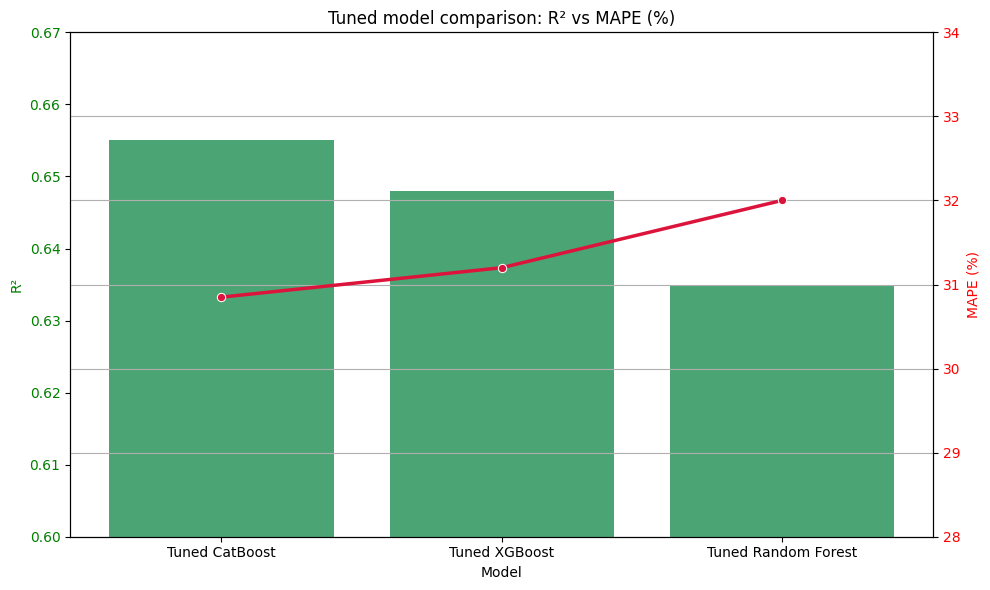

In [22]:

perf_optimisee = pd.DataFrame({
    "Model": ["Tuned CatBoost", "Tuned XGBoost", "Tuned Random Forest"],
    "R^2": [0.6554, 0.6473, 0.6402],
    "MAPE (%)": [31.78, 32.32, 32.88]
})

# Create the dual-axis chart
fig, ax1 = plt.subplots(figsize=(10, 6))

# Axis for R^2
sns.barplot(x="Model", y="R^2", data=perf_optimisee, ax=ax1, color="mediumseagreen")
ax1.set_ylabel("R^2", color='green')
ax1.tick_params(axis='y', labelcolor='green')
ax1.set_ylim(0.60, 0.67)

# Secondary axis for MAPE
ax2 = ax1.twinx()
sns.lineplot(x="Model", y="MAPE (%)", data=perf_optimisee, ax=ax2, color='crimson', marker='o', linewidth=2.5)
ax2.set_ylabel("MAPE (%)", color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(28, 34)

plt.title("Tuned model comparison: R^2 vs MAPE (%)")
plt.xticks(rotation=15)
plt.grid(True)
plt.tight_layout()
plt.show()

## Feature Importance Analysis

Feature importance plots help interpret which variables drive the predictions of the best-performing non-linear models. This is useful to confirm that the model relies on meaningful Airbnb listing characteristics rather than arbitrary noise.


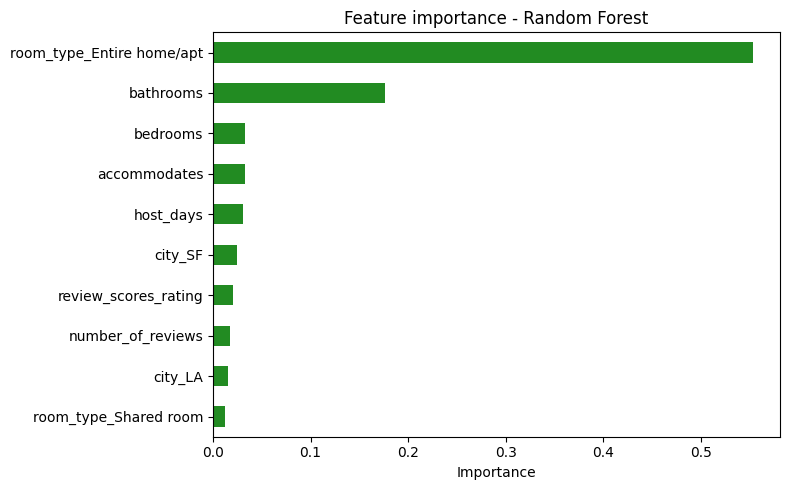

In [23]:
# Feature importance - Random Forest
rf_feat_imp = pd.Series(best_rf.feature_importances_, index=X_train_enc.columns)
rf_feat_imp.nlargest(10).plot(kind='barh', title="Feature importance - Random Forest", figsize=(8,5), color='forestgreen')
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


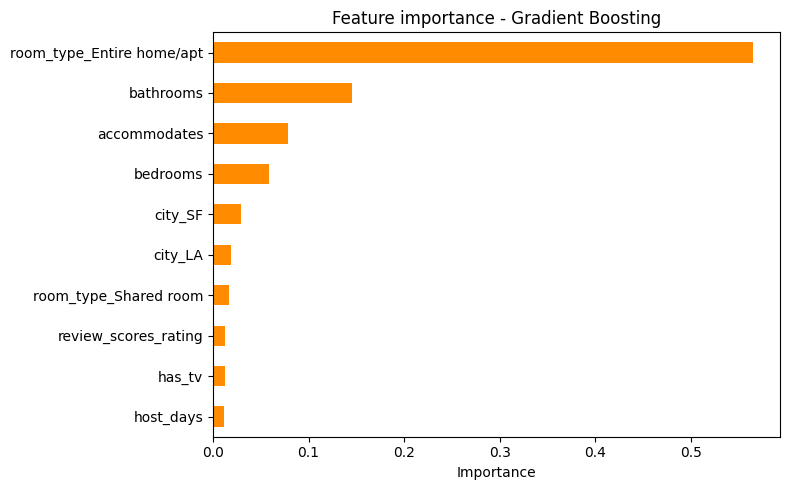

In [24]:
# Feature importance - Gradient Boosting
gb_feat_imp = pd.Series(models["Gradient Boosting"].feature_importances_, index=X_train_enc.columns)
gb_feat_imp.nlargest(10).plot(kind='barh', title="Feature importance - Gradient Boosting", figsize=(8,5), color='darkorange')
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


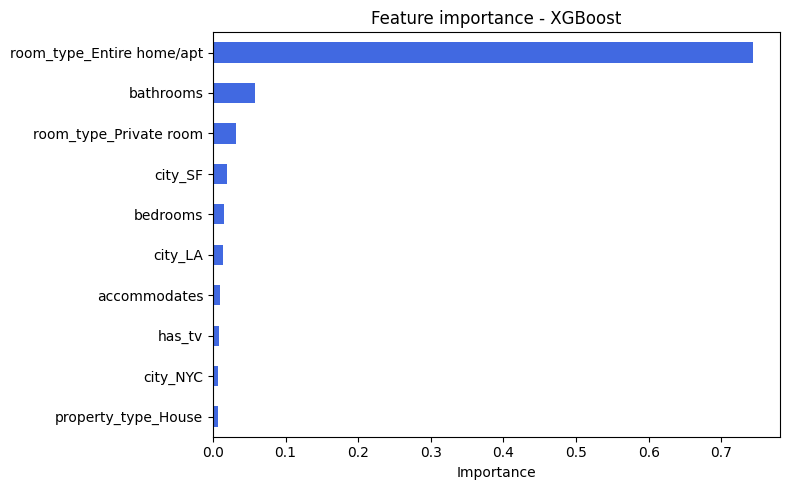

In [25]:
# Feature importance - XGBoost
xgb_feat_imp = pd.Series(best_xgb.feature_importances_, index=X_train_enc.columns)
xgb_feat_imp.nlargest(10).plot(kind='barh', title="Feature importance - XGBoost", figsize=(8,5), color='royalblue')
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


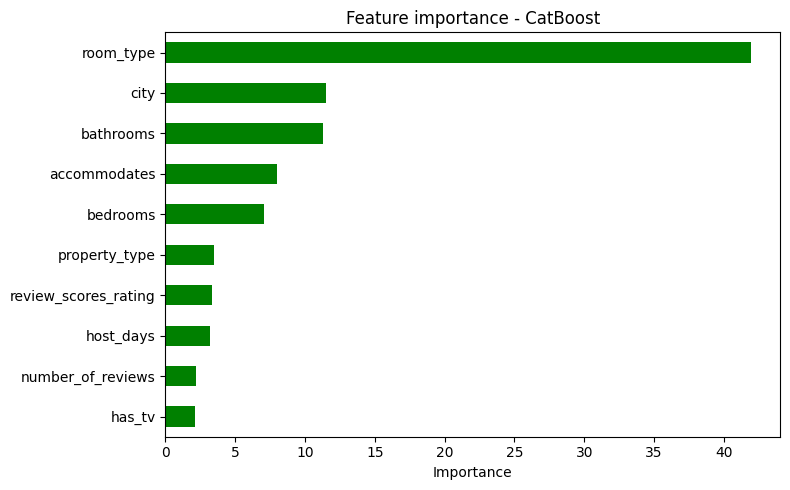

In [26]:
# Feature importance - CatBoost
cat_feat_imp = pd.Series(best_catboost.get_feature_importance(), index=X_train.columns)
cat_feat_imp.nlargest(10).plot(kind='barh', title="Feature importance - CatBoost", figsize=(8,5), color='green')
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## Comparison After Tuning

After hyperparameter tuning, the optimized CatBoost model remains the most convincing candidate:
- it reaches the highest reported `R^2`,
- it also achieves the lowest reported `MAPE`,
- and it handles categorical variables naturally, which fits this dataset particularly well.

For these reasons, the tuned CatBoost model is selected for the final test-set predictions.


## Residual Analysis

The residual distribution is inspected to check whether the errors remain centered around zero. A reasonably symmetric error pattern suggests that the final model does not systematically overestimate or underestimate listing prices.


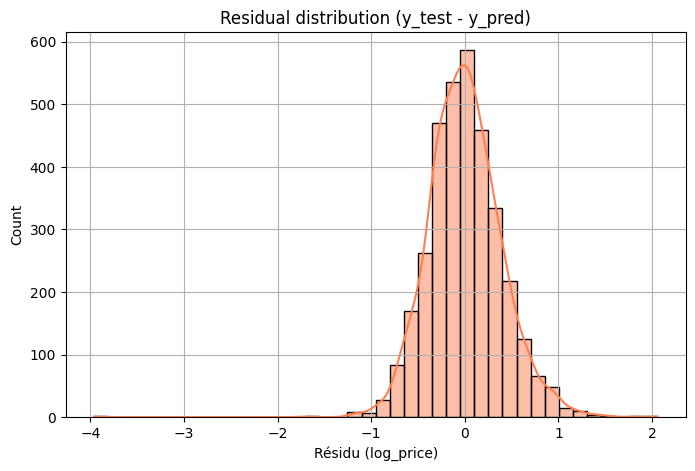

In [27]:
residuals = y_test - y_pred_opt_cat
plt.figure(figsize=(8,5))
sns.histplot(residuals, kde=True, bins=40, color="coral")
plt.title("Residual distribution for tuned CatBoost")
plt.xlabel("Residual (log_price)")
plt.grid(True)
plt.show()


## Predicted versus Observed Values

The scatter plot compares predicted values with the observed targets. The closer the points are to the diagonal, the more accurate the model is on the validation set.


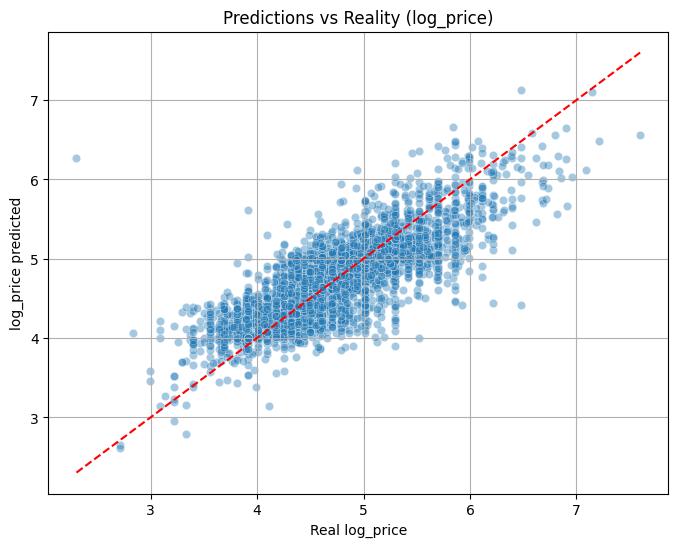

In [35]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred_opt_cat, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")
plt.xlabel("Observed log_price")
plt.ylabel("Predicted log_price")
plt.title("Predictions vs observed values (log_price)")
plt.grid(True)
plt.show()


## Final Predictions on the Test Set

Once the final model is selected, the same preprocessing steps are applied to `airbnb_test.csv` in order to generate the final submission file.


In [29]:
airbnb_test = pd.read_csv(TEST_DATA_PATH)


### Reusing the Same Transformations

The feature engineering applied to the training data must be reproduced exactly on the test set so that the final model receives the same type of inputs.


In [30]:

def has_amenity(amenities, keyword):
    if pd.isnull(amenities): return 0
    return int(keyword.lower() in amenities.lower())

bool_map = {"t": 1, "f": 0}

# Add amenity indicator columns
airbnb_test["has_wifi"] = airbnb_test["amenities"].apply(lambda x: has_amenity(x, "wifi"))
airbnb_test["has_kitchen"] = airbnb_test["amenities"].apply(lambda x: has_amenity(x, "kitchen"))
airbnb_test["has_tv"] = airbnb_test["amenities"].apply(lambda x: has_amenity(x, "tv"))
airbnb_test["has_aircon"] = airbnb_test["amenities"].apply(lambda x: has_amenity(x, "air conditioning"))
airbnb_test["has_heating"] = airbnb_test["amenities"].apply(lambda x: has_amenity(x, "heating"))
airbnb_test["has_parking"] = airbnb_test["amenities"].apply(lambda x: has_amenity(x, "parking"))

# Convert host_since into host age in days
airbnb_test["host_since"] = pd.to_datetime(airbnb_test["host_since"], errors="coerce")
airbnb_test["host_days"] = (pd.to_datetime("today") - airbnb_test["host_since"]).dt.days

# Convert boolean fields
for col in ["cleaning_fee", "instant_bookable", "host_identity_verified", "host_has_profile_pic"]:
    airbnb_test[col] = airbnb_test[col].map(bool_map)


### Final Column Alignment

The test-set columns are aligned with the training features and missing numerical values are filled with the same strategy used during training.


In [31]:
X_final = airbnb_test[X_train.columns]  # reuse the training columns
X_final = X_final.fillna(X_train.median(numeric_only=True))


In [32]:
y_final_pred = best_catboost.predict(X_final)


### Submission File

The final predictions are exported as a CSV file in the required submission format.


In [33]:
prediction_example = pd.read_csv(SUBMISSION_TEMPLATE_PATH)
prediction_example["logpred"] = y_final_pred
prediction_example.to_csv(PREDICTIONS_PATH, index=False)


# Conclusion

This project shows that Airbnb price prediction is a noisy but still learnable regression problem when structured listing features are prepared carefully.

The exploratory analysis highlighted several strong drivers of price:
- the city,
- the room type,
- the accommodation capacity,
- and a few core numerical variables such as bedrooms, bathrooms, and review-related features.

Among the tested models, CatBoost emerged as the best overall choice. It handled the categorical variables naturally and delivered the strongest validation results after tuning, with a reported `R^2` of `0.6554` and a `MAPE` of `31.78%` on the validation split.

Overall, the project confirms that feature engineering, careful model comparison, and targeted hyperparameter tuning are all necessary to obtain solid performance on heterogeneous marketplace data.
